In [1]:
import torch

# si ringrazia la gentile partecipazione del server Linux per la generazione del dataset (METIS non funziona su Windows)
#dataset = RedditSubGraphDataset(path='Reddit', num_graphs=1000, task_type='a')

dataset = torch.load("reddit_task3_clusters_a.pt", weights_only=False)
# classe 1: sopra media = 370 grafi
# classe 0: sotto media = 630 grafi

In [2]:
from torch_geometric.loader import DataLoader

batch_size = 64

#Creazione dei DataLoader per il training, la validazione e il test
train_loader = DataLoader(dataset["train"], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset["val"], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset["test"], batch_size=batch_size, shuffle=False)

Tentativo GCN

In [ ]:
from utils_task3_a import FlatGCNClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr = 5e-4
epochs = 50

model = FlatGCNClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GCN.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 16.04it/s]


Epoch 1/50 - Train Loss: 0.8522 - Val Loss: 0.8088 - Balanced Accuracy: 0.6789 - F1 Score: 0.7232
Nuovo miglior modello salvato con Val Loss: 0.8088
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 23.14it/s]


Epoch 2/50 - Train Loss: 0.7794 - Val Loss: 0.7596 - Balanced Accuracy: 0.6544 - F1 Score: 0.6724
Nuovo miglior modello salvato con Val Loss: 0.7596
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 22.70it/s]


...

Epoch 12/50 - Train Loss: 0.1925 - Val Loss: 0.6435 - Balanced Accuracy: 0.7776 - F1 Score: 0.7906
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 22.63it/s]


Epoch 13/50 - Train Loss: 0.2114 - Val Loss: 0.6383 - Balanced Accuracy: 0.8205 - F1 Score: 0.8305
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 22.81it/s]

Epoch 14/50 - Train Loss: 0.1886 - Val Loss: 0.5448 - Balanced Accuracy: 0.8363 - F1 Score: 0.8496
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


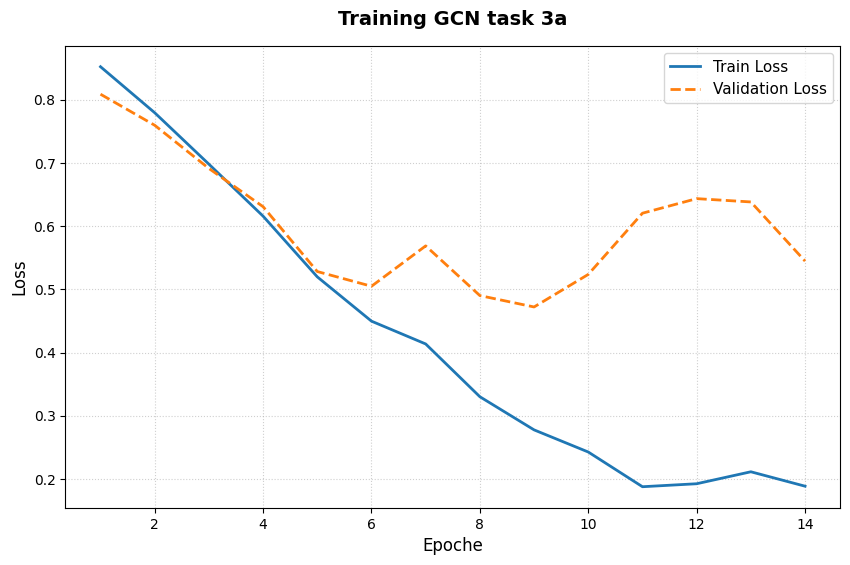

In [4]:
from utils_task1 import plot_history

plot_history(history,"Training GCN task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  6.25it/s]

Test Loss: 0.3475 - Balanced Accuracy: 0.9063 - F1 Score: 0.9102


[]

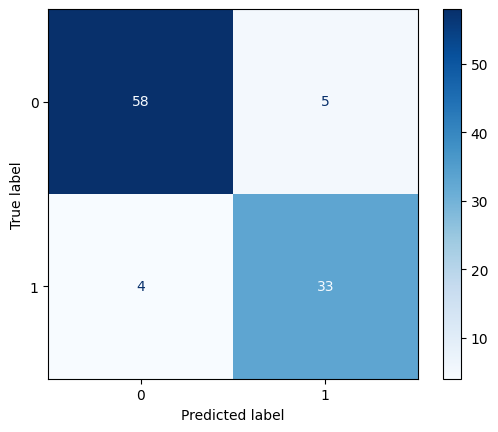

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device, test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

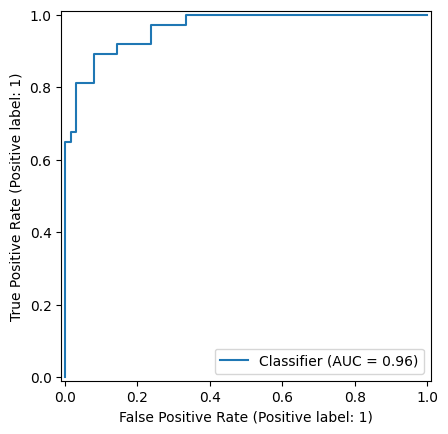

In [6]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo SAGE

In [ ]:
from utils_task3_a import FlatSAGEConvClassifier,train_loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = FlatSAGEConvClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_SAGE.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.78it/s]


Epoch 1/50 - Train Loss: 0.8677 - Val Loss: 0.8487 - Balanced Accuracy: 0.5817 - F1 Score: 0.4138
Nuovo miglior modello salvato con Val Loss: 0.8487
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.06it/s]


Epoch 2/50 - Train Loss: 0.8471 - Val Loss: 0.8292 - Balanced Accuracy: 0.6205 - F1 Score: 0.5315
Nuovo miglior modello salvato con Val Loss: 0.8292
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 27.71it/s]


...

Epoch 18/50 - Train Loss: 0.3151 - Val Loss: 0.8393 - Balanced Accuracy: 0.7617 - F1 Score: 0.7717
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 27.65it/s]


Epoch 19/50 - Train Loss: 0.3018 - Val Loss: 0.7581 - Balanced Accuracy: 0.7879 - F1 Score: 0.8082
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 28.17it/s]

Epoch 20/50 - Train Loss: 0.2142 - Val Loss: 0.8034 - Balanced Accuracy: 0.8078 - F1 Score: 0.8030
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


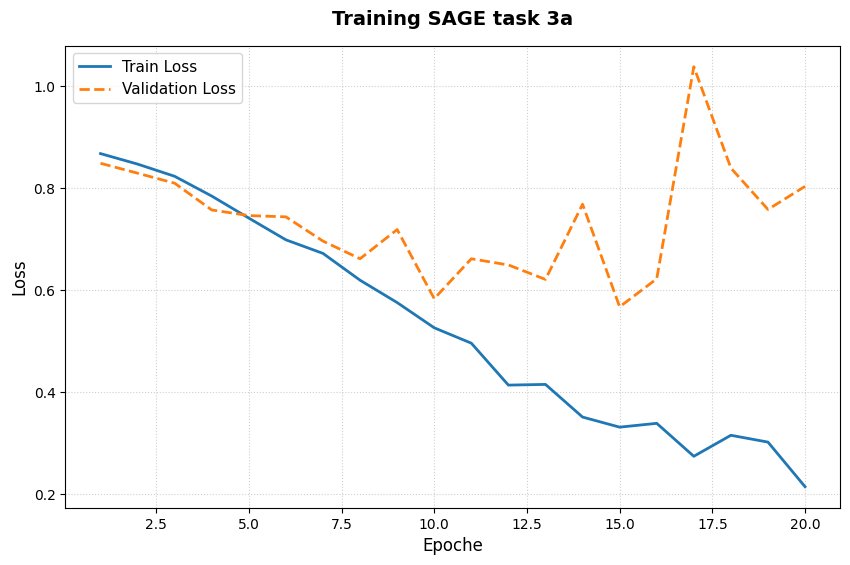

In [8]:
from utils_task1 import plot_history

plot_history(history,"Training SAGE task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  6.86it/s]

Test Loss: 0.5183 - Balanced Accuracy: 0.8563 - F1 Score: 0.8426


[]

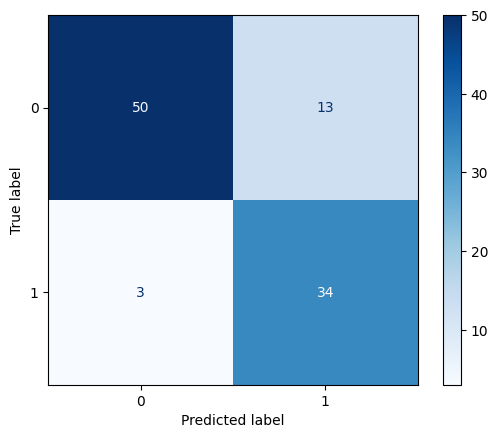

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

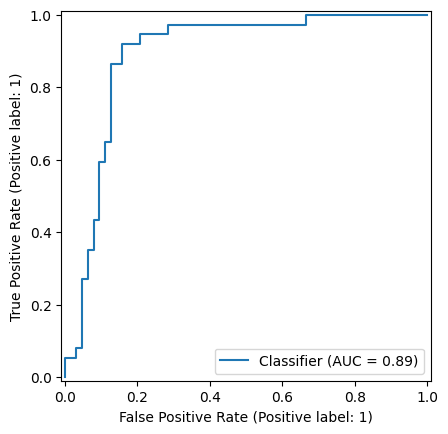

In [10]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo GAT

In [ ]:
from utils_task3_a import FlatGATClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = FlatGATClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GAT.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  2.83it/s]


Epoch 1/50 - Train Loss: 0.8536 - Val Loss: 0.8283 - Balanced Accuracy: 0.5697 - F1 Score: 0.4769
Nuovo miglior modello salvato con Val Loss: 0.8283
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  2.92it/s]


Epoch 2/50 - Train Loss: 0.8019 - Val Loss: 0.7740 - Balanced Accuracy: 0.7179 - F1 Score: 0.7457
Nuovo miglior modello salvato con Val Loss: 0.7740
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  2.90it/s]


...

Epoch 8/50 - Train Loss: 0.2399 - Val Loss: 1.3438 - Balanced Accuracy: 0.7585 - F1 Score: 0.7787
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:05<00:00,  2.95s/it]


Epoch 9/50 - Train Loss: 0.1847 - Val Loss: 1.3071 - Balanced Accuracy: 0.7743 - F1 Score: 0.7974
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:05<00:00,  2.84s/it]

Epoch 10/50 - Train Loss: 0.1409 - Val Loss: 1.0608 - Balanced Accuracy: 0.8149 - F1 Score: 0.8295
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


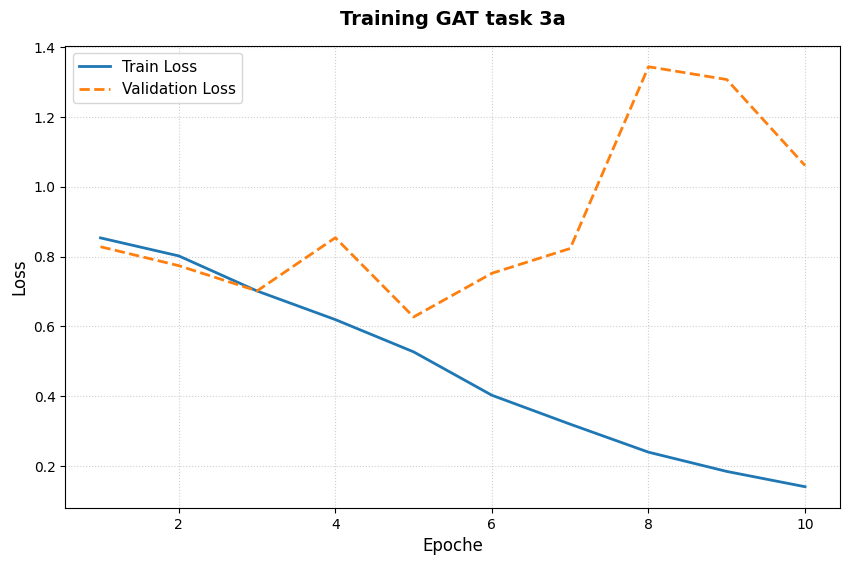

In [12]:
from utils_task1 import plot_history

plot_history(history,"Training GAT task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:06<00:00,  3.46s/it]

Test Loss: 0.7937 - Balanced Accuracy: 0.7435 - F1 Score: 0.7439


[]

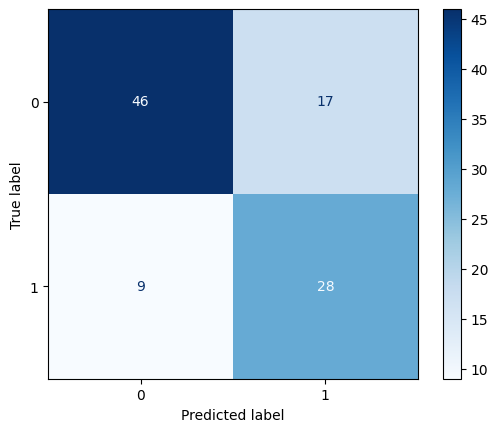

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

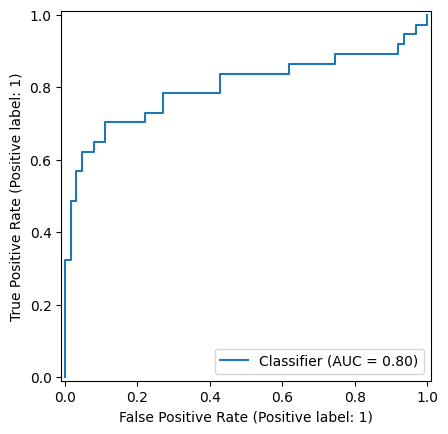

In [14]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo GIN

In [ ]:
from utils_task3_a import FlatGINClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = FlatGINClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GIN.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 23.84it/s]


Epoch 1/50 - Train Loss: 0.4391 - Val Loss: 0.4610 - Balanced Accuracy: 0.8649 - F1 Score: 0.8959
Nuovo miglior modello salvato con Val Loss: 0.4610
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 31.33it/s]


Epoch 2/50 - Train Loss: 0.2298 - Val Loss: 0.2855 - Balanced Accuracy: 0.9189 - F1 Score: 0.9387
Nuovo miglior modello salvato con Val Loss: 0.2855
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 16.64it/s]


...

Epoch 7/50 - Train Loss: 0.1123 - Val Loss: 0.1422 - Balanced Accuracy: 0.9459 - F1 Score: 0.9595
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 16.97it/s]


Epoch 8/50 - Train Loss: 0.1191 - Val Loss: 0.1348 - Balanced Accuracy: 0.9515 - F1 Score: 0.9598
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 10.00it/s]

Epoch 9/50 - Train Loss: 0.0776 - Val Loss: 0.1072 - Balanced Accuracy: 0.9785 - F1 Score: 0.9800
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


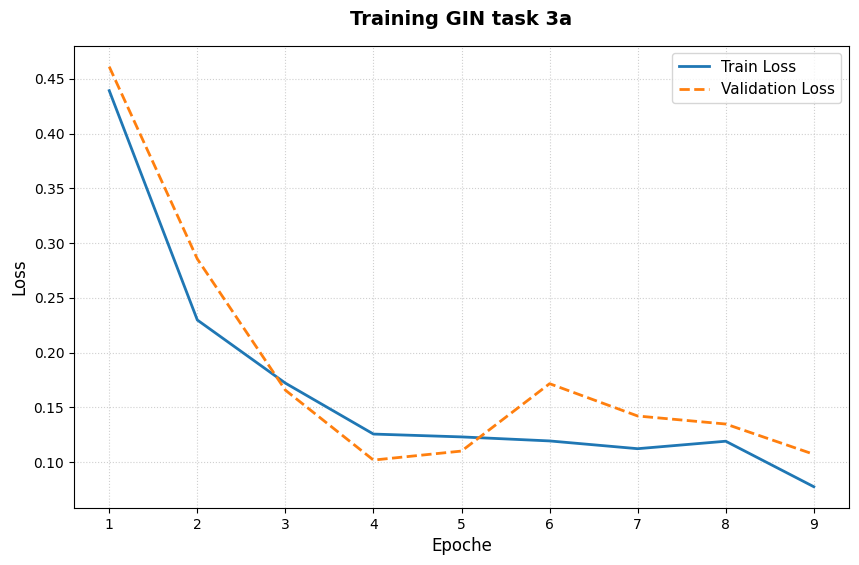

In [16]:
from utils_task1 import plot_history

plot_history(history,"Training GIN task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  5.67it/s]

Test Loss: 0.0859 - Balanced Accuracy: 0.9921 - F1 Score: 0.9900


[]

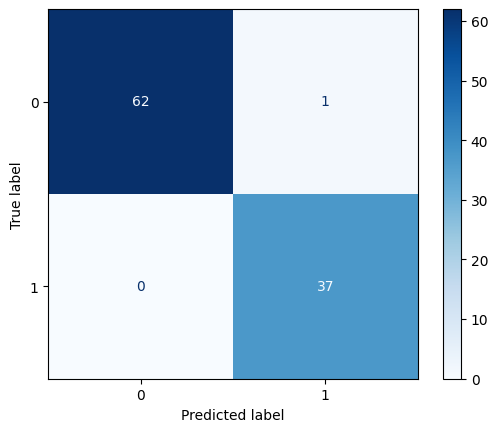

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

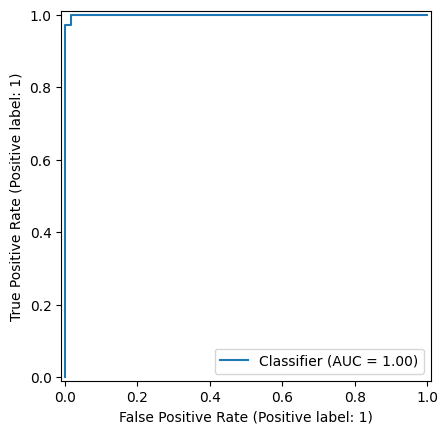

In [18]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()